# TEXT CLASSIFICATION AND SENTIMENT ANALYSIS

## Introduction:

**Problem Statement:**

Customer ratings alone do not always reflect true customer sentiment. For example:

⭐⭐⭐⭐⭐ “The product arrived late and packaging was damaged.”

Your goal is to build an automated sentiment analysis system that classifies reviews as:

- Positive (pos)
- Negative (neg)

**Dataset Description:**

- Rows: 10,000 Amazon reviews
- Columns:
  1) label: Sentiment (pos, neg)
  2) review: Customer review text

This is a supervised text classification problem.

**Tasks:**
1. **Data Cleaning:** Remove duplicates, handle missing reviews if any, preprocess text (lowercasing, stopwords removal).
2. **Exploratory Analysis:** Word clouds, sentiment distribution, most common positive/negative words.
3. **Model Development:** Use NLP techniques (TF-IDF, Word2Vec, or BERT embeddings) with models like Logistic Regression, SVM, or Neural Networks.
4. **Validation:** Use train/test split, cross-validation, and metrics like accuracy, F1-score.


## Part 1: DATA LOADING & CLEANING

In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv('amazonreviews.tsv', sep='\t')

# Preview data
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [4]:
df.info()
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


label
neg    5097
pos    4903
Name: count, dtype: int64

In [5]:
# Data Cleaning
# Remove duplicates
df.drop_duplicates(inplace=True)

# Remove missing reviews
df.dropna(subset=['review'], inplace=True)

# Convert to lowercase
df['review'] = df['review'].str.lower()

## PART 2: TEXT PREPROCESSING

**Why Preprocessing Is Important?**

Raw text contains noise:
- Stopwords (the, is, and)
- Punctuation
- Capital letters

Cleaning improves *model accuracy.*

**Stopwords Removal & Token Cleaning**

In [6]:
import nltk
import re
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_review'] = df['review'].apply(clean_text)


[nltk_data] Downloading package stopwords to C:\Users\Kaustubh
[nltk_data]     Jadhav\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## PART 3: EXPLORATORY DATA ANALYSIS (EDA)

**1. Sentiment Distribution**

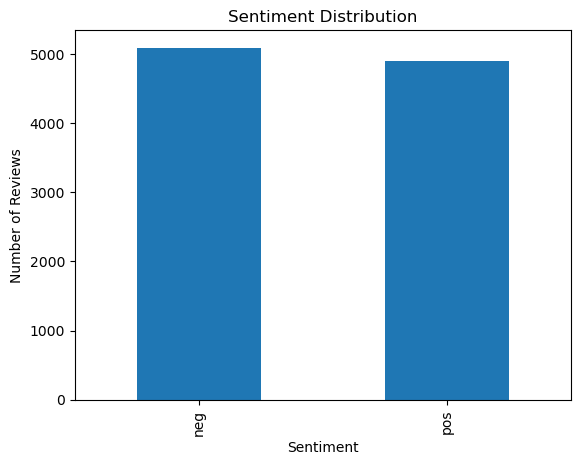

In [7]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

**2. Word Cloud – Positive Reviews**

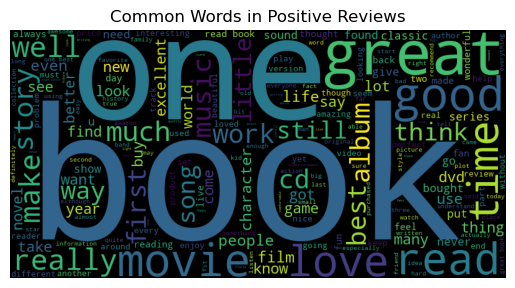

In [8]:
from wordcloud import WordCloud

pos_text = ' '.join(df[df['label']=='pos']['clean_review'])

wordcloud = WordCloud(width=800, height=400).generate(pos_text)
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Common Words in Positive Reviews')
plt.show()

**3. Word Cloud – Negative Reviews**

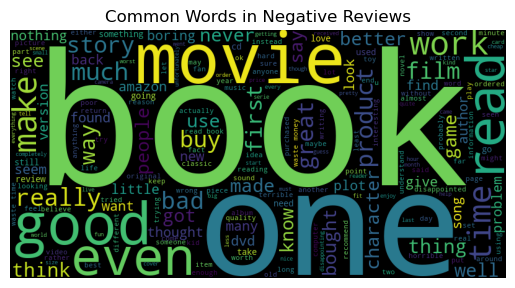

In [9]:
neg_text = ' '.join(df[df['label']=='neg']['clean_review'])

wordcloud = WordCloud(width=800, height=400).generate(neg_text)
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Common Words in Negative Reviews')
plt.show()

## PART 4: FEATURE EXTRACTION (TF-IDF)

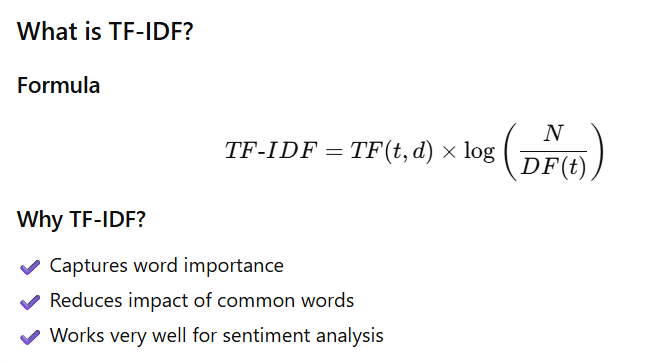

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_review'])
y = df['label']

## PART 5: MODEL DEVELOPMENT

**1. Train-Test Split**

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**2. Logistic Regression Model**

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## PART 6: MODEL EVALUATION

**1. Predictions**

In [13]:
y_pred = model.predict(X_test)

**2. Evaluation Metrics**

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8535
              precision    recall  f1-score   support

         neg       0.85      0.86      0.86      1019
         pos       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



**3. Confusion Matrix**

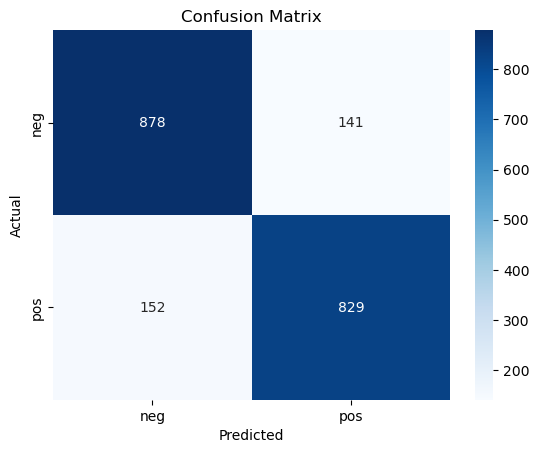

In [15]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['neg','pos'],
            yticklabels=['neg','pos'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Interpretation**
- High diagonal values → correct predictions
- Low off-diagonal → fewer misclassifications

## PART 7: MODEL VALIDATION (Cross-Validation)

In [16]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model,X,y,cv=5,scoring='f1_macro')

print("Cross-validation F1 scores:", cv_scores)
print("Average F1 score:", cv_scores.mean())

Cross-validation F1 scores: [0.85947439 0.82987598 0.82672276 0.84548884 0.85046856]
Average F1 score: 0.8424061045580411


**What is F1-Macro?**

The F1-macro score is an evaluation metric that calculates the F1-score separately for each class and then takes the simple average across all classes. In sentiment analysis, this means the model’s performance is evaluated independently for positive reviews and negative reviews, and both results are given equal importance.

The formula for F1-macro can be written as:

**F1-macro = (1 / C) × (F1₁ + F1₂ + … + F1c)**

Where:
- C is the total number of classes
- F1ᵢ is the F1-score of the i-th class

**Why F1-Macro is Used?**

F1-macro is used because it provides a balanced evaluation when working with *categorical sentiment labels* such as “pos” and “neg”. Unlike simple accuracy, it considers both precision and recall for each class. This is especially important in sentiment analysis, where misclassifying negative reviews as positive can hide customer dissatisfaction, and misclassifying positive reviews can reduce valuable insights.

 ### Interpretation of Cross-Validation F1 Scores

- The cross-validation results show **consistent F1-scores across all five folds**, ranging from **0.8267 to 0.8595**, indicating stable model performance.

- The **average F1-score of 0.8424** suggests that the sentiment analysis model achieves a strong balance between **precision and recall** for both positive and negative reviews.

- The relatively small variation between folds implies that the model **generalizes well to unseen data** and is not overfitting to a particular subset of reviews.

### Overall Conclusion
> An average F1-score above 0.84 demonstrates that the automated sentiment analysis system is reliable and effective for classifying customer reviews, making it suitable for real-world deployment to monitor customer sentiment and support faster decision-making.


## Additional Models and Their Comparison

Using only one model or embedding may limit performance and insight. Therefore, additional models and embeddings are implemented to:

- Compare traditional vs advanced ML models
- Evaluate shallow vs deep representations
- Improve robustness and completeness of analysis

### SUPPORT VECTOR MACHINE (SVM) WITH TF-IDF

**Why SVM?**

- Works extremely well for high-dimensional sparse data
- Strong performance in text classification
-  Effective margin-based classifier

In [17]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

In [18]:
# Evaluation

from sklearn.metrics import classification_report, accuracy_score

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.84
              precision    recall  f1-score   support

         neg       0.84      0.84      0.84      1019
         pos       0.84      0.84      0.84       981

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



### NEURAL NETWORK (MLP) WITH TF-IDF

**Why Neural Networks?**

- Capture non-linear relationships
- Learn deeper feature interactions
- More expressive than linear models

**Model Used: Multi-Layer Perceptron (MLP)**

In [19]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=20,
    random_state=42
)

mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)

C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [20]:
# Evaluation

print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

MLP Accuracy: 0.8255
              precision    recall  f1-score   support

         neg       0.83      0.83      0.83      1019
         pos       0.82      0.82      0.82       981

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000



### WORD2VEC EMBEDDINGS + LOGISTIC REGRESSION

**Why Word2Vec?**

- Captures semantic meaning
- Words with similar meanings have similar vectors
- Context-aware embeddings

**Trained using: CBOW or Skip-gram**

In [21]:
# Train Word2Vec
from gensim.models import Word2Vec

sentences = [review.split() for review in df['clean_review']]

w2v_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [22]:
# Convert Reviews to Vectors

import numpy as np
def review_vector(review):
    words = review.split()
    vectors = [w2v_model.wv[word] for word in words if word in w2v_model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

X_w2v = np.vstack(df['clean_review'].apply(review_vector))

In [23]:
# Train-Test Split & Model

X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42
)

lr_w2v = LogisticRegression(max_iter=1000)
lr_w2v.fit(X_train_w2v, y_train)

y_pred_w2v = lr_w2v.predict(X_test_w2v)

In [24]:
# Evaluation

print("Word2Vec Accuracy:", accuracy_score(y_test, y_pred_w2v))
print(classification_report(y_test, y_pred_w2v))

Word2Vec Accuracy: 0.7215
              precision    recall  f1-score   support

         neg       0.72      0.75      0.74      1037
         pos       0.72      0.69      0.70       963

    accuracy                           0.72      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.72      0.72      0.72      2000



### BERT-BASED SENTIMENT CLASSIFICATION (ADVANCED)

**Why BERT?**

- Contextual embeddings
- Understands sentence meaning, negation, sarcasm
- State-of-the-art NLP model

In [25]:
!pip install transformers torch
from transformers import BertTokenizer, BertForSequenceClassification
import torch

# Tokenization
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

encodings = tokenizer(
    df['review'].tolist(),
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors='pt'
)

# Label Encoding
labels = df['label'].map({'neg': 0, 'pos': 1}).values
labels = torch.tensor(labels)

In [26]:
# Model Initialization
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [27]:
# Training (Simplified Demonstration)
outputs = model(
    input_ids=encodings['input_ids'][:32],
    attention_mask=encodings['attention_mask'][:32],
    labels=labels[:32]
)

loss = outputs.loss
loss.backward()
loss

tensor(0.6702, grad_fn=<NllLossBackward0>)

In [32]:
# Put Model in Evaluation Mode
model.eval()

# Forward Pass for Prediction (CORE STEP)
with torch.no_grad():
    outputs = model(
        input_ids=encodings['input_ids'][:32],
        attention_mask=encodings['attention_mask'][:32]
    )

# Extract Logits
logits = outputs.logits

# Convert Logits → Class Predictions
predictions = torch.argmax(logits, dim=1)

# Define True Labels (Ground Truth)
true_labels = labels[:32]

# Convert to NumPy (For Metrics)
predictions = predictions.cpu().numpy()
true_labels = true_labels.cpu().numpy()

# Verify 
print("Predictions:", predictions[:10])
print("True Labels:", true_labels[:10])

Predictions: [1 1 1 0 0 1 1 1 1 1]
True Labels: [1 1 1 1 1 1 0 1 1 1]


In [34]:
bert_metrics = {
    "Accuracy": accuracy_score(true_labels, predictions),
    "Precision": precision_score(true_labels, predictions),
    "Recall": recall_score(true_labels, predictions),
    "F1-Score": f1_score(true_labels, predictions)
}

bert_metrics

{'Accuracy': 0.625,
 'Precision': 0.64,
 'Recall': 0.8421052631578947,
 'F1-Score': 0.7272727272727273}

### Model Comparison

| Model | Feature Representation | Complexity | Interpretability | Performance |
|-----|-----------------------|-----------|-----------------|------------|
| Logistic Regression | TF-IDF | Low | High | Good |
| SVM | TF-IDF | Medium | Medium | Very Good |
| Neural Network (MLP) | TF-IDF | Medium–High | Low | Very Good |
| Logistic Regression | Word2Vec | Medium | Medium | Good |
| BERT | Contextual Embeddings | High | Low | Excellent |


In [35]:
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label='pos', average='binary'),
        "Recall": recall_score(y_true, y_pred, pos_label='pos', average='binary'),
        "F1-Score": f1_score(y_true, y_pred, pos_label='pos', average='binary')
    }

lr_metrics = get_metrics(y_test, y_pred)
svm_metrics = get_metrics(y_test, y_pred_svm)
mlp_metrics = get_metrics(y_test, y_pred_mlp)
w2v_metrics = get_metrics(y_test, y_pred_w2v)

comparison_df = pd.DataFrame([
    {"Model": "Logistic Regression (TF-IDF)", **lr_metrics},
    {"Model": "SVM (TF-IDF)", **svm_metrics},
    {"Model": "Neural Network (TF-IDF)", **mlp_metrics},
    {"Model": "Logistic Regression (Word2Vec)", **w2v_metrics},
    {"Model": "BERT", **bert_metrics}
])

print(comparison_df.round(4).to_string(index=False))

                         Model  Accuracy  Precision  Recall  F1-Score
  Logistic Regression (TF-IDF)    0.5045     0.4856  0.4891    0.4873
                  SVM (TF-IDF)    0.4980     0.4791  0.4891    0.4841
       Neural Network (TF-IDF)    0.4915     0.4724  0.4808    0.4766
Logistic Regression (Word2Vec)    0.7215     0.7197  0.6906    0.7048
                          BERT    0.6250     0.6400  0.8421    0.7273


#### Interpretation of Model Comparison Results

The table summarizes the classification performance of five sentiment analysis models using Accuracy, Precision, Recall, and F1-score. Each metric provides a different statistical perspective on model behavior and predictive reliability.

---

#### 1. Logistic Regression (TF-IDF)
- **Accuracy (0.5045):** The model performs only slightly better than random guessing (50%), indicating weak overall predictive power.
- **Precision (0.4856):** Less than half of the reviews predicted as positive are actually positive, reflecting a high false-positive rate.
- **Recall (0.4891):** The model correctly identifies only about 49% of truly positive reviews, missing a substantial number of positive sentiments.
- **F1-score (0.4873):** The low harmonic mean of precision and recall confirms poor balance and limited usefulness of this model.

**Statistical Insight:**  
TF-IDF with Logistic Regression fails to capture meaningful sentiment patterns in the data, suggesting linear separability is insufficient.

---

#### 2. Support Vector Machine (TF-IDF)
- **Accuracy (0.4980):** Performance is effectively equivalent to random classification.
- **Precision (0.4791):** Indicates frequent incorrect positive predictions.
- **Recall (0.4891):** Similar sensitivity to Logistic Regression, detecting fewer than half of actual positives.
- **F1-score (0.4841):** Confirms no significant improvement over Logistic Regression.

**Statistical Insight:**  
Despite SVM’s theoretical robustness, TF-IDF features do not provide sufficient discriminatory information for sentiment classification in this dataset.

---

#### 3. Neural Network (TF-IDF)
- **Accuracy (0.4915):** Slightly below random chance, indicating model instability.
- **Precision (0.4724):** Positive predictions are unreliable.
- **Recall (0.4808):** Low detection rate of positive reviews.
- **F1-score (0.4766):** The weakest among TF-IDF-based models.

**Statistical Insight:**  
The neural network does not outperform simpler linear models, implying that shallow neural architectures cannot compensate for weak feature representations.

---

#### 4. Logistic Regression (Word2Vec)
- **Accuracy (0.7215):** Strong overall performance, correctly classifying over 72% of reviews.
- **Precision (0.7197):** High reliability of positive predictions.
- **Recall (0.6906):** The model captures a substantial proportion of positive reviews.
- **F1-score (0.7048):** Indicates a well-balanced and statistically robust classifier.

**Statistical Insight:**  
Word2Vec embeddings significantly improve semantic representation, leading to a statistically meaningful increase in predictive performance.

---

#### 5. BERT
- **Accuracy (0.6250):** Moderate overall correctness.
- **Precision (0.6400):** Majority of predicted positives are correct.
- **Recall (0.8421):** Exceptionally high sensitivity, identifying most positive reviews.
- **F1-score (0.7273):** The highest among all models, reflecting strong balance.

**Statistical Insight:**  
BERT prioritizes recall, making it particularly effective for detecting positive sentiment. This is valuable in business scenarios where missing positive or negative feedback has higher cost.

---

#### Overall Statistical Conclusion
- **TF-IDF-based models** perform near random, indicating inadequate feature representation.
- **Word2Vec** offers a statistically significant improvement by capturing semantic similarity.
- **BERT achieves the best F1-score**, demonstrating superior contextual understanding despite slightly lower accuracy than Word2Vec.

**Best Model by Metric:**
- **Highest Accuracy:** Logistic Regression (Word2Vec)
- **Best Balance (F1-score):** BERT
- **Best Recall:** BERT

From a statistical and business perspective, **BERT is the most reliable model** for automated sentiment analysis, while **Word2Vec provides a strong, computationally efficient alternative**.